In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Rows and columns:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nChurn breakdown:\n", df['Churn'].value_counts())

Rows and columns: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Churn breakdow

In [ ]:
# 1. Fix TotalCharges — convert from text to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Remove the ~11 rows where TotalCharges was blank
df.dropna(inplace=True)

# 3. Convert Churn from Yes/No to 1/0 (models need numbers)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Drop customerID — it's just an ID, useless for analysis
df.drop('customerID', axis=1, inplace=True)

# Confirm everything looks good
print("Rows remaining:", len(df))
print("Churn column now:", df['Churn'].value_counts().to_dict())
print("TotalCharges type:", df['TotalCharges'].dtype)

Rows remaining: 7032
Churn column now: {0: 5163, 1: 1869}
TotalCharges type: float64


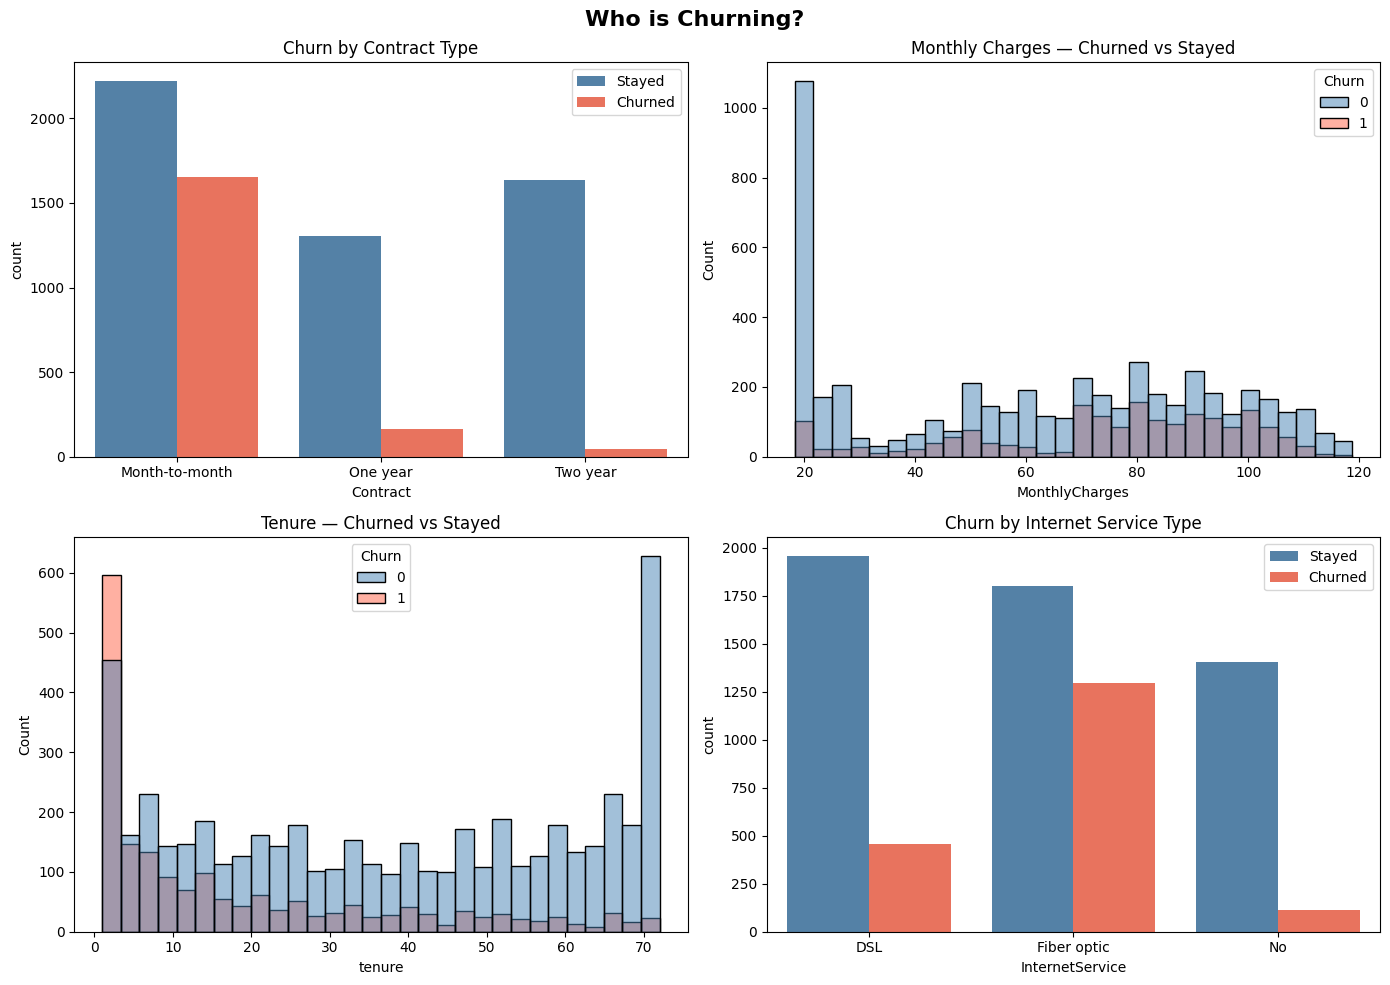

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Who is Churning?', fontsize=16, fontweight='bold')

# Chart 1: Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0,0],
              palette={0:'steelblue', 1:'tomato'})
axes[0,0].set_title('Churn by Contract Type')
axes[0,0].legend(labels=['Stayed', 'Churned'])

# Chart 2: Churn by Monthly Charges
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30,
             ax=axes[0,1], palette={0:'steelblue', 1:'tomato'})
axes[0,1].set_title('Monthly Charges — Churned vs Stayed')

# Chart 3: Churn by Tenure (how long they've been a customer)
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             ax=axes[1,0], palette={0:'steelblue', 1:'tomato'})
axes[1,0].set_title('Tenure — Churned vs Stayed')

# Chart 4: Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn',
              ax=axes[1,1], palette={0:'steelblue', 1:'tomato'})
axes[1,1].set_title('Churn by Internet Service Type')
axes[1,1].legend(labels=['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

In [ ]:
# Overall churn rate
churn_rate = df['Churn'].mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")

# Churn rate by contract type
print("\nChurn rate by contract:")
print(df.groupby('Contract')['Churn'].mean().mul(100).round(1).astype(str) + '%')

# Churn rate by internet service
print("\nChurn rate by internet service:")
print(df.groupby('InternetService')['Churn'].mean().mul(100).round(1).astype(str) + '%')

Overall churn rate: 26.6%

Churn rate by contract:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: object

Churn rate by internet service:
InternetService
DSL            19.0%
Fiber optic    41.9%
No              7.4%
Name: Churn, dtype: object


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Step 6a: Convert all text columns to numbers
df_model = pd.get_dummies(df, drop_first=True)

# Step 6b: Separate inputs (X) from what we're predicting (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Step 6c: Split into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6d: Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 6e: Test it
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 1), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

Accuracy: 78.5 %

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.86      1033
     Churned       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



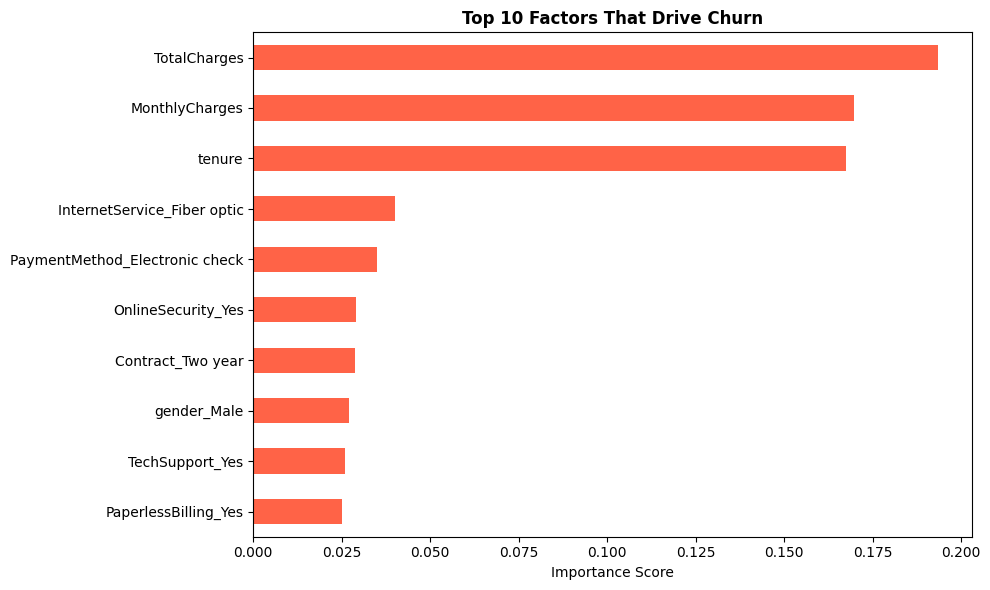


Top 5 churn drivers:
  1. TotalCharges: 19.3%
  2. MonthlyCharges: 17.0%
  3. tenure: 16.8%
  4. InternetService_Fiber optic: 4.0%
  5. PaymentMethod_Electronic check: 3.5%


In [ ]:
# Top 10 factors driving churn
feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='tomato')
plt.title('Top 10 Factors That Drive Churn', fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 churn drivers:")
for i, (col, val) in enumerate(feat_imp.head(5).items(), 1):
    print(f"  {i}. {col}: {round(val*100, 1)}%")

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Add churn probability score to every customer
df['churn_probability'] = model.predict_proba(X)[:, 1]

# How much revenue is at risk per customer (12 months projection)
df['expected_loss'] = df['churn_probability'] * df['MonthlyCharges'] * 12

total_at_risk = df['expected_loss'].sum()
high_risk_customers = (df['churn_probability'] > 0.7).sum()
avg_monthly_high_risk = df[df['churn_probability'] > 0.7]['MonthlyCharges'].mean()

print(f"Total revenue at risk (next 12 months): ${total_at_risk:,.0f}")
print(f"Number of high-risk customers (>70% chance of churning): {high_risk_customers}")
print(f"Average monthly charge of high-risk customers: ${avg_monthly_high_risk:.2f}")

Total revenue at risk (next 12 months): $1,691,244
Number of high-risk customers (>70% chance of churning): 1352
Average monthly charge of high-risk customers: $77.40


In [ ]:
high_risk = df[df['churn_probability'] > 0.7].copy()

strategies = {
    'No Action': {'discount': 0.00, 'save_rate': 0.00},
    '10% Discount': {'discount': 0.10, 'save_rate': 0.50},
    '20% Discount': {'discount': 0.20, 'save_rate': 0.65},
    'Free Month': {'discount': 0.08, 'save_rate': 0.55},
}

print("=" * 55)
print(f"{'Strategy':<20} {'Revenue Saved':>15} {'Net Benefit':>15}")
print("=" * 55)

results = []
for name, s in strategies.items():
    revenue_if_saved = high_risk['MonthlyCharges'] * (1 - s['discount']) * 12 * s['save_rate']
    revenue_lost = high_risk['MonthlyCharges'] * 12 * (1 - s['save_rate'])
    net = revenue_if_saved.sum() - revenue_lost.sum()
    results.append({'Strategy': name, 'Net Benefit': net})
    print(f"{name:<20} ${revenue_if_saved.sum():>13,.0f} ${net:>13,.0f}")

print("=" * 55)
best = max(results, key=lambda x: x['Net Benefit'])
print(f"\n✅ Best strategy: {best['Strategy']} (${best['Net Benefit']:,.0f} net benefit)")

Strategy               Revenue Saved     Net Benefit
No Action            $            0 $   -1,255,808
10% Discount         $      565,114 $      -62,790
20% Discount         $      653,020 $      213,487
Free Month           $      635,439 $       70,325

✅ Best strategy: 20% Discount ($213,487 net benefit)


In [ ]:
scaler = MinMaxScaler()

df['risk_score'] = scaler.fit_transform(df[['churn_probability']])
df['revenue_score'] = scaler.fit_transform(df[['MonthlyCharges']])

# 70% weight on risk, 30% on revenue value
df['priority_score'] = (0.7 * df['risk_score']) + (0.3 * df['revenue_score'])

top_50 = df.nlargest(50, 'priority_score')[
    ['MonthlyCharges', 'tenure', 'churn_probability', 'priority_score']
].reset_index(drop=True)

top_50.index += 1  # start ranking from 1
print("Top 10 customers to contact first:\n")
print(top_50.head(10).round(2).to_string())

# Save to CSV
top_50.to_csv('priority_customers.csv', index=True)
print("\n✅ Saved as priority_customers.csv")

Top 10 customers to contact first:

    MonthlyCharges  tenure  churn_probability  priority_score
1           100.60       8               1.00            0.95
2            99.25       7               1.00            0.94
3            99.80      41               0.99            0.94
4           101.95       7               0.98            0.94
5            95.45       1               1.00            0.93
6            99.50      11               0.98            0.93
7            94.30       4               1.00            0.93
8           105.90       3               0.95            0.93
9           101.00      43               0.97            0.93
10          105.50       8               0.95            0.93

✅ Saved as priority_customers.csv


In [ ]:
# Export the main dataset with all scores
df.to_csv('churn_final.csv', index=False)
print("✅ churn_final.csv saved")

✅ churn_final.csv saved
